In [28]:
import numpy
import matplotlib.pyplot as plt
import pandas as pd
import torch


In [29]:
CONSTELLATION = torch.tensor(
    [
        [-0.948683, -0.948683],
        [-0.948683, -0.316228],
        [-0.948683, 0.316228],
        [-0.948683, 0.948683],
        [-0.316228, -0.948683],
        [-0.316228, -0.316228],
        [-0.316228, 0.316228],
        [-0.316228, 0.948683],
        [0.316228, -0.948683],
        [0.316228, -0.316228],
        [0.316228, 0.316228],
        [0.316228, 0.948683],
        [0.948683, -0.948683],
        [0.948683, -0.316228],
        [0.948683, 0.316228],
        [0.948683, 0.948683],
    ],
    dtype=torch.float32,
)

BIT_LABELS = torch.tensor(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 1],
        [0, 1, 1, 0],
        [1, 1, 0, 0],
        [1, 1, 0, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 1],
        [1, 0, 1, 1],
        [1, 0, 1, 0],
    ],
    dtype=torch.uint8,
)


In [30]:
def symbols_to_classes(symbols: torch.Tensor) -> torch.Tensor:
    constellation = CONSTELLATION.to(symbols.device)
    diff = symbols.unsqueeze(1) - constellation.unsqueeze(0)
    dist = torch.sum(diff.square(), dim=2)
    return torch.argmin(dist, dim=1)

In [31]:
def calculate_ber_from_classes(tx_classes: torch.Tensor, rx_classes: torch.Tensor) -> float:
    bit_labels = BIT_LABELS.to(tx_classes.device)
    tx_bits = bit_labels[tx_classes]
    rx_bits = bit_labels[rx_classes]
    return (tx_bits != rx_bits).float().mean().item()

In [32]:
df = pd.read_csv('Symbols_1m_1ch_PR/Symbols_1m_1ch_PR_1.csv', header=None)

In [33]:
df.head()

,0,1,2,3
0,-0.948683,-0.948683,-0.337421,-0.776812
1,0.948683,-0.948683,0.757867,-1.056065
2,-0.316228,0.948683,-0.295274,0.921046
3,-0.948683,-0.948683,-0.897900,-1.168450
4,-0.316228,0.316228,-0.236391,0.389069


In [34]:
array = df.to_numpy()

In [35]:

received_re, received_im, transmitted_re, transmitted_im = [], [], [], []
for row in array:
    received_re.append(row[2])
    received_im.append(row[3])
    transmitted_re.append(row[0])
    transmitted_im.append(row[1])

In [36]:
tx_symbols = numpy.column_stack([transmitted_re, transmitted_im])

unique_symbols, classes = numpy.unique(tx_symbols, axis=0, return_inverse=True)

In [37]:
unique_symbols.shape

(16, 2)

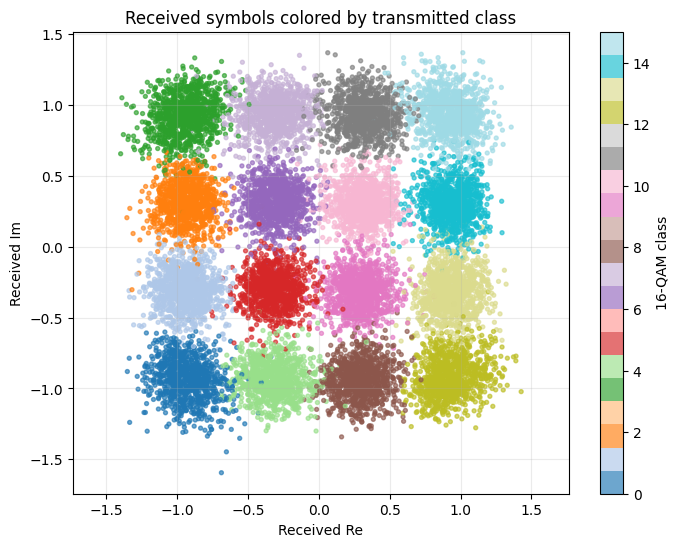

In [38]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    received_re,
    received_im,
    c=classes,
    cmap='tab20',
    s=8,
    alpha=0.65
)

plt.xlabel('Received Re')
plt.ylabel('Received Im')
plt.title('Received symbols colored by transmitted class')
plt.axis('equal')
plt.grid(alpha=0.25)
plt.colorbar(scatter, label='16-QAM class')
plt.show()


In [39]:
rx_classes = symbols_to_classes(torch.tensor(list(zip(received_re, received_im)), dtype=torch.float32))
calculate_ber_from_classes(torch.tensor(classes), torch.tensor(rx_classes))

/var/folders/qx/26qdthnd4f1bb2j6x95x6_jr0000gn/T/ipykernel_24556/3283823826.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  calculate_ber_from_classes(torch.tensor(classes), torch.tensor(rx_classes))


0.0081024169921875

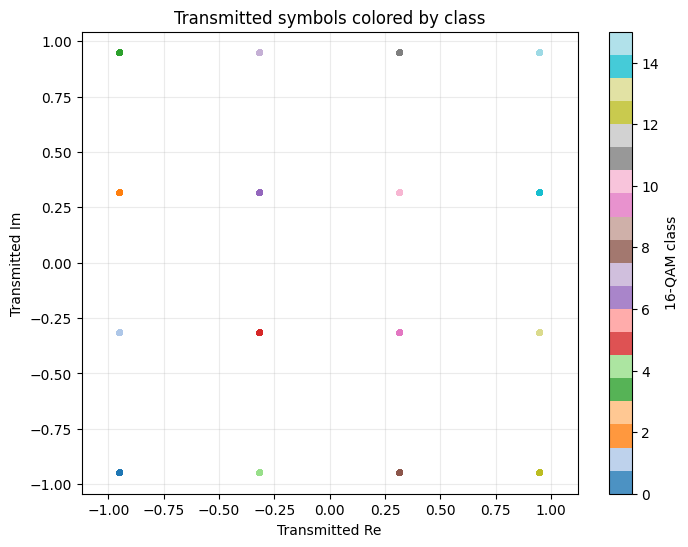

In [40]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    transmitted_re,
    transmitted_im,
    c=classes,
    cmap='tab20',
    s=12,
    alpha=0.8
)

plt.xlabel('Transmitted Re')
plt.ylabel('Transmitted Im')
plt.title('Transmitted symbols colored by class')
plt.axis('equal')
plt.grid(alpha=0.25)
plt.colorbar(scatter, label='16-QAM class')
plt.show()


In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
array = [[x, y] for x, y in zip(received_re, received_im)]


In [42]:
X_pca = pca.fit_transform(array)

<Figure size 800x600 with 0 Axes>

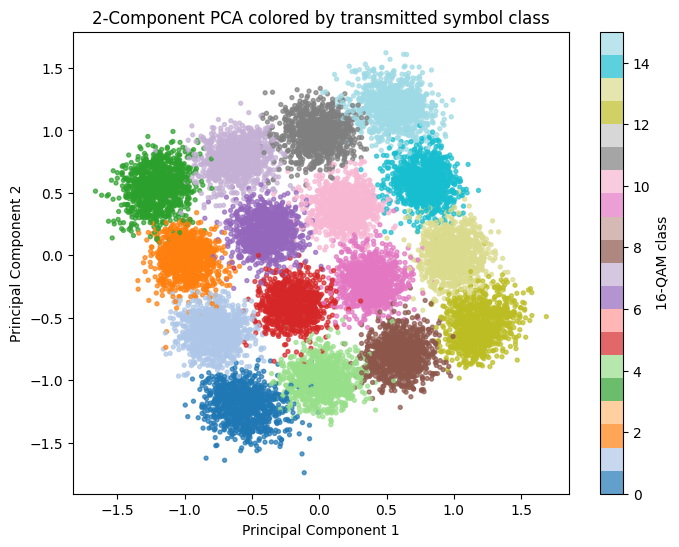

In [43]:
plt.figure(figsize=(8, 6))
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=classes,
    cmap='tab20',
    s=8,
    alpha=0.7
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2-Component PCA colored by transmitted symbol class')
plt.colorbar(scatter, label='16-QAM class')
plt.show()

In [46]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

X = np.column_stack([received_re, received_im])
y = classes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    KNeighborsClassifier(n_neighbors=15),
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ber = calculate_ber_from_classes(
    torch.tensor(y_test),
    torch.tensor(y_pred),
)

print("BER:", ber)


BER: 0.007729861885309219


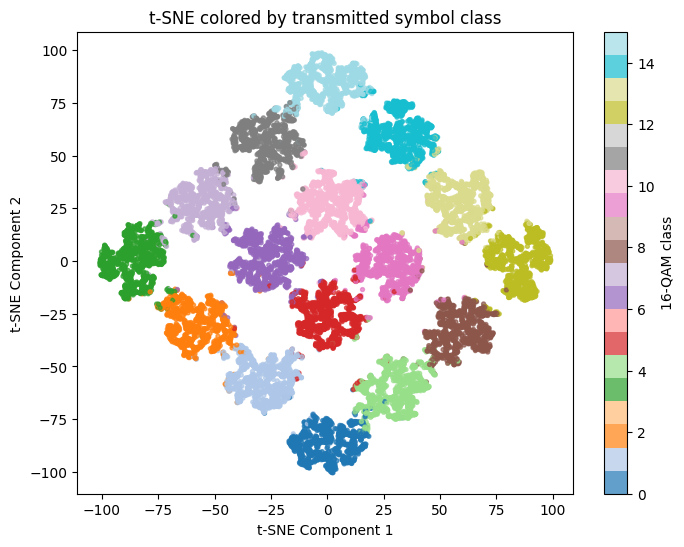

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.column_stack([received_re, received_im])
X = StandardScaler().fit_transform(X)

X_embedded = TSNE(
    n_components=2,
    perplexity=50,        # попробовать 30, 50, 100, 200
    learning_rate='auto',
    init='pca',
    random_state=42,
    max_iter=1000,
).fit_transform(X)


plt.figure(figsize=(8, 6))


scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=classes,
    cmap='tab20',
    s=8,
    alpha=0.7
)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE colored by transmitted symbol class')
plt.colorbar(scatter, label='16-QAM class')
plt.show()


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_embedded, classes,
    test_size=0.3,
    random_state=42,
    stratify=classes,
)

clf = KNeighborsClassifier(n_neighbors=15)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("BER t-SNE:", calculate_ber_from_classes(
    torch.tensor(y_test),
    torch.tensor(y_pred),
))


BER t-SNE: 0.008594385348260403


/Users/vik0t/ml lessons/MNSK/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


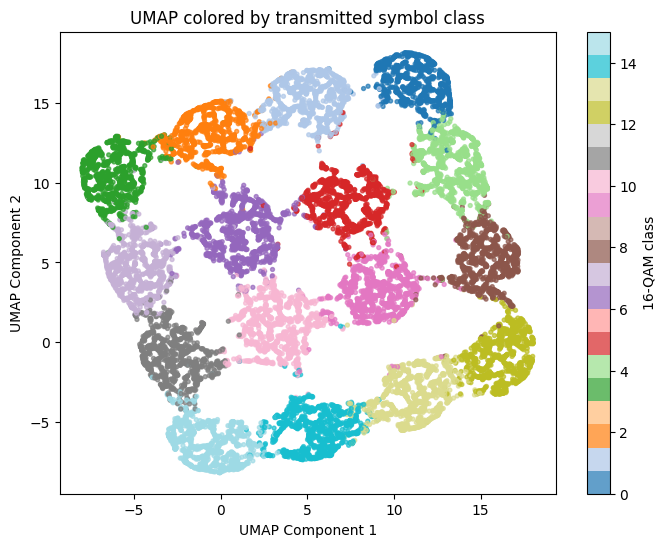

In [ ]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
embedding = reducer.fit_transform(numpy.array(array))

plt.figure(figsize=(8, 6))


scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=classes,
    cmap='tab20',
    s=8,
    alpha=0.7
)

plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP colored by transmitted symbol class')
plt.colorbar(scatter, label='16-QAM class')
plt.show()


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import umap
import numpy as np
import torch

X = np.column_stack([received_re, received_im])
y = np.asarray(classes)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

umap_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
)

X_train_umap = umap_reducer.fit_transform(X_train_scaled)
X_test_umap = umap_reducer.transform(X_test_scaled)

clf = KNeighborsClassifier(n_neighbors=15)
clf.fit(X_train_umap, y_train)
y_pred = clf.predict(X_test_umap)

symbol_accuracy = accuracy_score(y_test, y_pred)
ber_umap = calculate_ber_from_classes(
    torch.tensor(y_test, dtype=torch.long),
    torch.tensor(y_pred, dtype=torch.long),
)

print('Symbol accuracy UMAP + kNN:', symbol_accuracy)
print('BER UMAP + kNN:', ber_umap)


/Users/vik0t/ml lessons/MNSK/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Symbol accuracy UMAP + kNN: 0.9646053702196908
BER UMAP + kNN: 0.008950365707278252


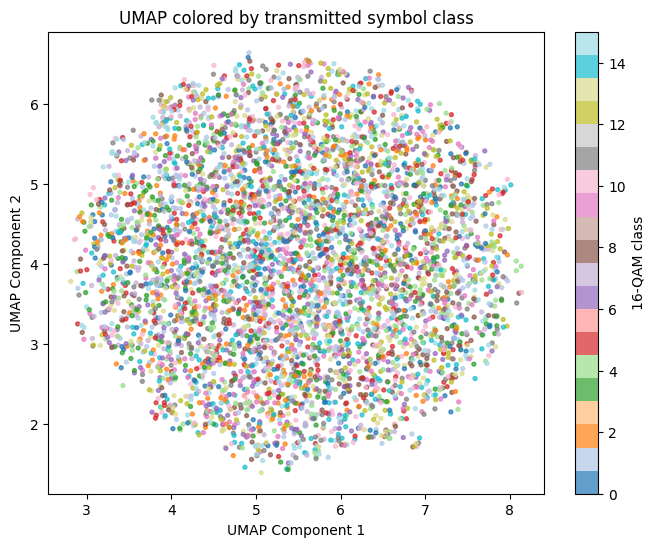

In [ ]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
embedding = reducer.fit_transform(X_window[sample_idx])

plt.figure(figsize=(8, 6))


scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=y_window[sample_idx],
    cmap='tab20',
    s=8,
    alpha=0.7
)

plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP colored by transmitted symbol class')
plt.colorbar(scatter, label='16-QAM class')
plt.show()
